In [1]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.covariance import LedoitWolf
import seaborn as sns
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
import os
from tqdm import tqdm

years = [2019, 2020, 2021, 2022, 2023, 2024]

modes = {}

for year in years:
    modes[f"fast_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/fast_emd.parquet")
    modes[f"medium_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/medium_emd.parquet")
    modes[f"slow_{year}"] = pd.read_parquet(f"../../data/03_modes/{year}/slow_emd.parquet")

In [4]:
from scipy.signal import hilbert

def hilbert_features(imf_series, dt=1.0):
    imf = imf_series.values

    # Analytic signal
    analytic = hilbert(imf)

    # Instantaneous amplitude
    amplitude = np.abs(analytic)

    # Instantaneous phase
    phase = np.unwrap(np.angle(analytic))

    # Instantaneous frequency
    frequency = np.diff(phase) / (2.0 * np.pi * dt)

    # Align lengths
    amplitude = pd.Series(amplitude, index=imf_series.index)
    frequency = pd.Series(
        np.concatenate([[np.nan], frequency]),
        index=imf_series.index
    )

    return amplitude, frequency

In [ ]:
hilbert_results = {}

for key, df in modes.items():
    amp_df = pd.DataFrame(index=df.index)
    freq_df = pd.DataFrame(index=df.index)

    for ticker in df.columns:
        amp, freq = hilbert_features(df[ticker])
        amp_df[ticker] = amp
        freq_df[ticker] = freq

    hilbert_results[f"{key}_amp"] = amp_df
    hilbert_results[f"{key}_freq"] = freq_df

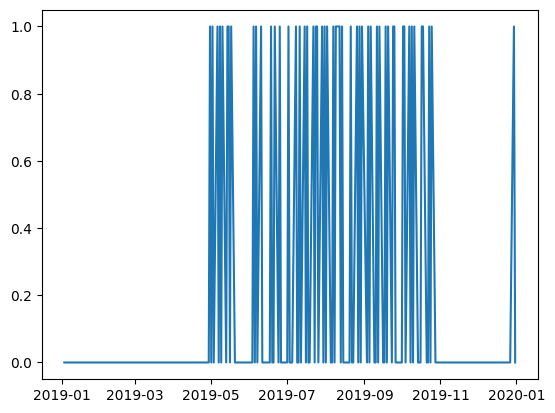

In [9]:
freq = hilbert_results["fast_2019_freq"]["ABVC"]
amp  = hilbert_results["fast_2019_amp"]["ABVC"]

signal = (freq > freq.rolling(20).mean()) & (amp < amp.rolling(20).mean())

plt.plot(signal)